In [1]:
import os
from argparse import ArgumentParser

# Third parties
import numpy as np
import pandas as pd
# Import from other modules
from model.common import fromYaml
from data.EOSdataset import DataSet
from model.gpu_utils import setup_gpu_memory_growth
from model.common import fromFolder



/opt/conda/envs/pennylane/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 17:20:22.760120: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 17:20:22.845424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 17:20:24.618421: I tensorflow/core/util/por

# Using transformer embedding training on everything with the AD dataset

In [2]:
input_path = '/eos/user/c/cebrown/RobustQML/AD_dataset/processed/'
embedding_model_path = 'AD_Contrastive_Embedding/Transformer/all/TransformerEmbedding'
output_path = 'AD/transformer/all'
os.makedirs(output_path, exist_ok=True)

In [3]:
embedding_model = fromFolder(embedding_model_path)

I0000 00:00:1776180030.743661   25838 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78763 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:ad:00.0, compute capability: 9.0
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/opt/conda/envs/pennylane/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Run the embedding prediction

In [ ]:
labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, 'hToTauTau':3,'leptoquark':4,'blackbox':5}


In [ ]:

training_columns = []
dataset_list = []
for datasets in labels.keys():
    data_test = DataSet.fromH5(input_path+datasets+'/train/')
    data_test.normalise()

    data_test.set_label(labels[datasets])
    dataset_list.append(data_test)
    training_columns = data_test.training_columns
        
full_data_frame = pd.concat([dataset.data_frame for dataset in dataset_list])
full_data_frame = full_data_frame.sample(frac=1)

full_embeddings = embedding_model.encoder_predict(full_data_frame[training_columns].to_numpy(),training_columns) 



# Save the embeddings for later use

In [5]:
os.makedirs(output_path+'/embeddings', exist_ok=True)
np.save(output_path+'/embeddings/full_embeddings.npy',full_embeddings)
full_data_frame.to_pickle(output_path+'/embeddings/dataset.pkl')

NameError: name 'full_embeddings' is not defined

# Load them or skip here when the embedding model has already run

In [6]:
full_embeddings = np.load(output_path+'/embeddings/full_embeddings.npy')
full_data_frame = pd.read_pickle(output_path+'/embeddings/dataset.pkl')

# Train an MLP autoencoder on the embedding

# Only use background for AE training

In [7]:
background_indices = np.where(full_data_frame["event_label"] == 0)
background_embeddings = full_embeddings[background_indices]
background_data_frame = full_data_frame.iloc[background_indices]

In [ ]:
CAE_model = fromYaml('model/configs/EmbeddingClassicalAEModel.yaml',output_path+'/models/CAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
CAE_model.build_model(input_shape)
CAE_model.compile_model(input_length)
CAE_model.only_CAE_fit(background_embeddings)
CAE_model.save()
CAE_model.plot_loss()

In [8]:
CAE_model = fromFolder(output_path+'/models/CAE')

# Train a BDT on the embedding

In [8]:
IF_model = fromYaml('model/configs/IsolationTreeModel.yaml',output_path+'/models/IF')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
IF_model.build_model(input_shape)
IF_model.compile_model(input_length)
IF_model.fit_on_embedding(background_embeddings)
IF_model.save()
IF_model.plot_loss()

Re-created existing directory: AD/transformer/all/models/IF.
Train model on 8071149 examples


[Warning] On large datasets, using discretized numerical features (i.e. `discretize_numerical_columns=True`) can significantly speed-up training without impact on model quality.


Model trained in 0:00:00.017195
Model saved to AD/transformer/all/models/IF/model/saved_model/
Not implemented for tree based methods


In [9]:
IF_model = fromFolder(output_path+'/models/IF')

Loading model from AD/transformer/all/models/IF/model/saved_model/


# Train a QAE on the embedding

circuit_weights: [-0.02771183 -0.00336946 -0.00899225 -0.01160348  0.00200153  0.01800171
  0.01916037  0.02003925 -0.00209292 -0.00034192  0.01386205 -0.00304488
  0.00541448 -0.00047785  0.01395495 -0.00890128  0.00204579 -0.00109052
 -0.01866086  0.01245346 -0.00706092  0.01422953 -0.00359931  0.02043447
 -0.00108948 -0.00364582  0.00109913  0.00741852  0.00580176  0.00487027
 -0.00443251 -0.00313423]
Device: lightning.gpu
Device wires: 16
Shots: Shots(total=None)
Level: gradient

Resource specifications:
  Total wire allocations: 16
  Total gates: 77
  Circuit depth: 21

  Gate types:
    RY: 16
    CNOT: 28
    RZ: 16
    RX: 8
    Hadamard: 2
    CSWAP: 7

  Measurements:
    expval(Projector): 1
Iter:    1 | Cost: 0.4984194 | Validation Cost: 0.4946152
Iter:    2 | Cost: 0.4926539 | Validation Cost: 0.4835467
Iter:    3 | Cost: 0.4849787 | Validation Cost: 0.4730511
Iter:    4 | Cost: 0.4657922 | Validation Cost: 0.4485119
Iter:    5 | Cost: 0.4404174 | Validation Cost: 0.421801

<Figure size 640x480 with 0 Axes>

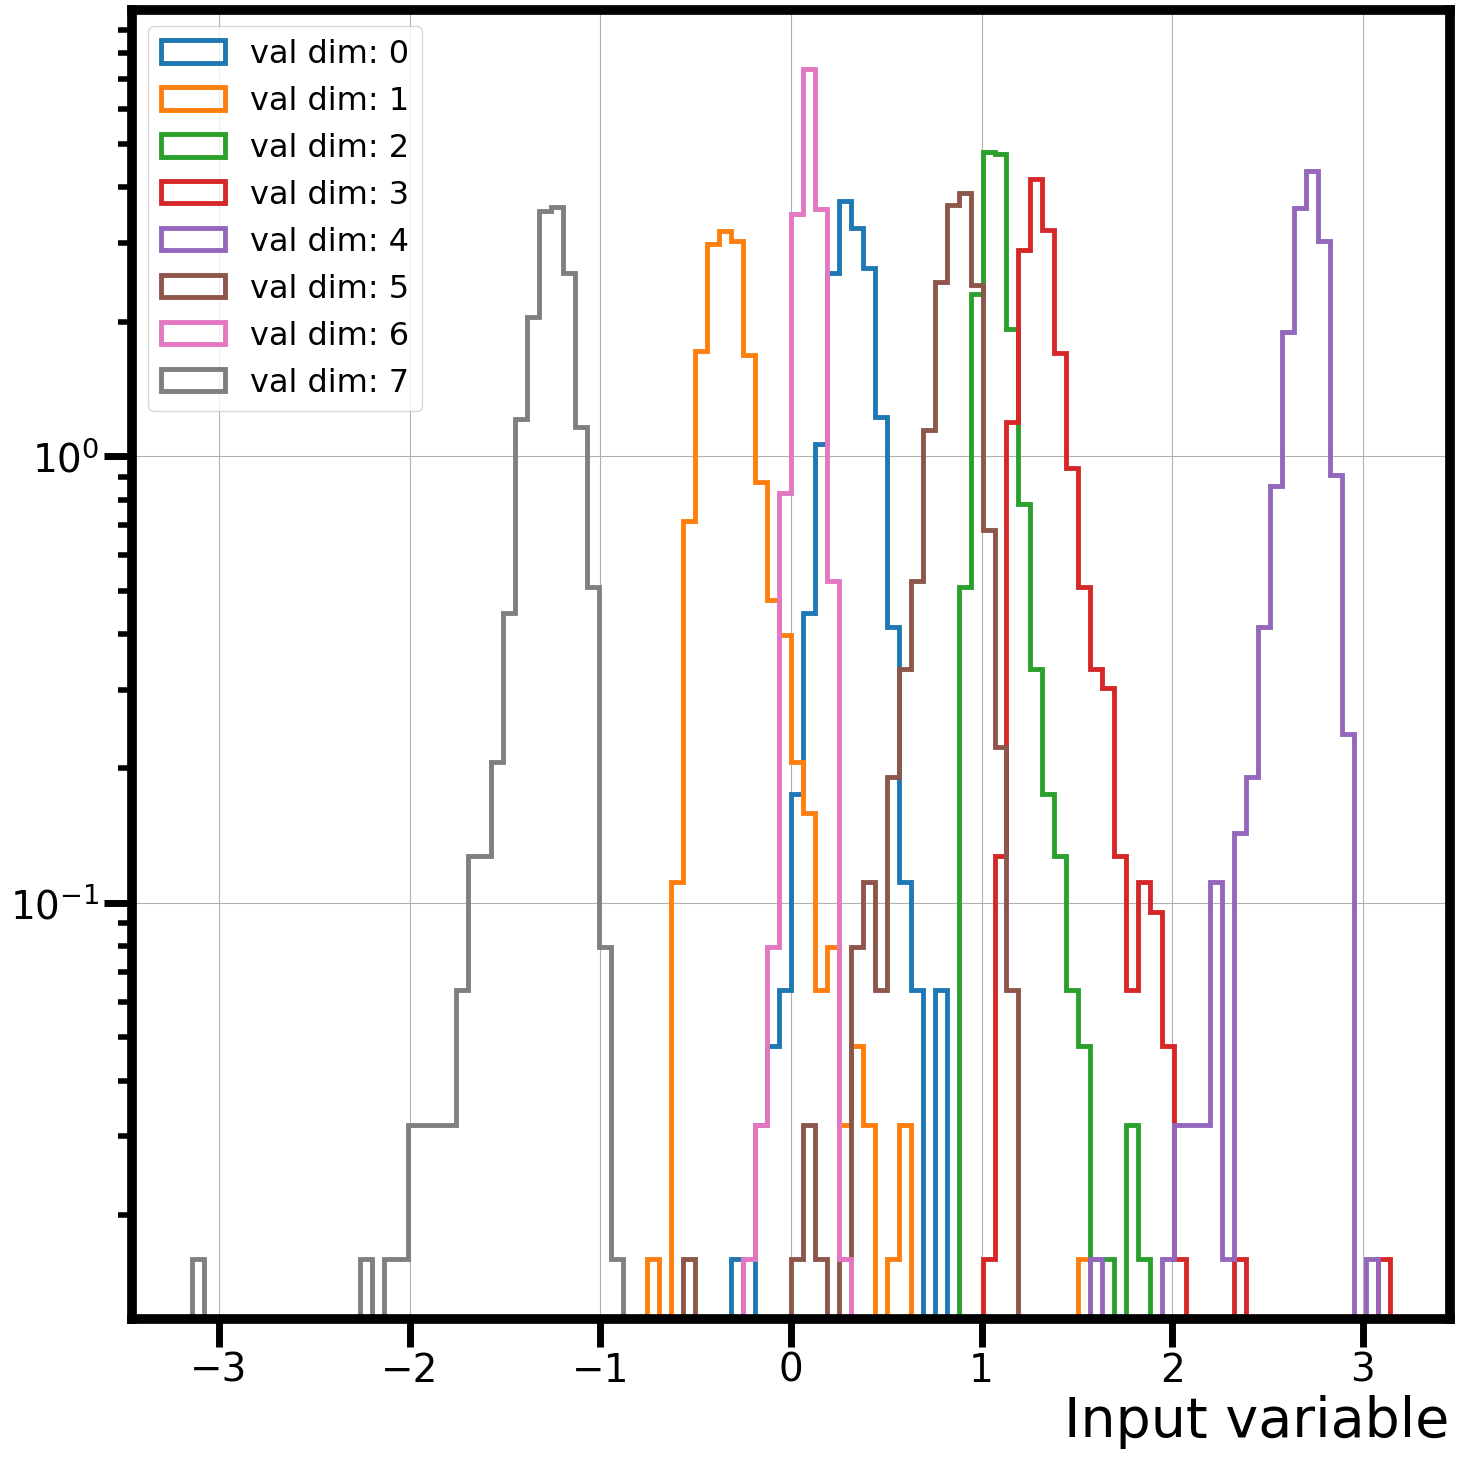

<Figure size 1700x1700 with 0 Axes>

In [10]:
QAE_model = fromYaml('model/configs/EmbeddingPennyLaneQAEModel.yaml',output_path+'/models/QAE')
input_shape = background_embeddings.shape[0]
input_length = len(background_data_frame)
input_length = len(background_data_frame)
QAE_model.build_model(input_shape)
QAE_model.compile_model(input_length)
QAE_model.only_QAE_fit(background_embeddings)
QAE_model.save()
QAE_model.plot_loss()

In [10]:
QAE_model = fromFolder(output_path+'/models/QAE')

# Evaluate the models

In [11]:
from plot.basic import error_residual, plot_histo, rates,efficiency, clusters, plot_2d

In [12]:
labels = {"background" : 0, "ato4l" :1, "hChToTauNu" : 2, "hToTauTau" : 3, "leptoquark" : 4, "blackbox": 5}

output_dict = {'CAE' : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}},
               'IF'  : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}},
               'QAE' : {"background" : {}, "ato4l" :{}, "hChToTauNu" : {}, "hToTauTau" : {}, "leptoquark" : {}, "blackbox": {}}}

for label in labels.keys():
    print("==== Predicting for "+label+" ====")
    indices = np.where(full_data_frame["event_label"] == labels[label])
    test_index = np.random.randint(0, len(indices[0]), size=10000)
    embeddings = full_embeddings[indices[0][test_index]]
    data_frame = full_data_frame.iloc[indices[0][test_index]]

    print("Classical Autoencoder Predict")
    output_dict['CAE'][label] = {'predictions' : CAE_model.only_CAE_predict(embeddings)}
    print("Isolation Forest Predict")
    output_dict['IF'][label]  = {'predictions' : IF_model.predict_on_embedding(embeddings)}
    print("Quantum Autoencoder Predict")
    output_dict['QAE'][label] = {'predictions' : QAE_model.only_QAE_predict(embeddings)}



2026-04-14 17:21:06.792623: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2a0c003c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-14 17:21:06.792708: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA H100 80GB HBM3, Compute Capability 9.0
2026-04-14 17:21:06.810922: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 17:21:06.897423: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 39/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

I0000 00:00:1776180067.691208   26059 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


ValueError: high <= 0

# Plot per model output predictions labeled per event type

In [ ]:


plot_histo([output_dict['CAE'][dataset]['predictions'] for dataset in output_dict['CAE'].keys()], 
               [dataset for dataset in output_dict['CAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)

plot_histo([output_dict['IF'][dataset]['predictions'] for dataset in output_dict['IF'].keys()], 
               [dataset for dataset in output_dict['IF'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)

plot_histo([output_dict['QAE'][dataset]['predictions'] for dataset in output_dict['QAE'].keys()], 
               [dataset for dataset in output_dict['QAE'].keys()], 
               '', 
               'AnomalyScore', 
               'a.u.', 
               log = 'linear', 
               x_range=(0, 1), 
               bins = 50)